In [35]:
import os
import sys

# Set up project path
project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of modules to ensure fresh imports
import importlib
if 'src.utils.data_loader' in sys.modules:
    del sys.modules['src.utils.data_loader']
if 'src.utils' in sys.modules:
    del sys.modules['src.utils']
if 'src' in sys.modules:
    del sys.modules['src']

print(f"Project Root: {project_root}")

Project Root: /Users/gayathri/Documents/SJSU/255/HybridReco


## Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.data_loader import DataLoader


# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data Files

In [37]:
# Load data files
users_path = os.path.join(project_root, 'data/users.csv')
products_path = os.path.join(project_root, 'data/products.csv')
transactions_path = os.path.join(project_root, 'data/transactions.csv')

print(f"Loading data files from: {os.path.join(project_root, 'data/')}")

users_df = DataLoader.load_users(users_path)
products_df = DataLoader.load_products(products_path)
transactions_df = DataLoader.load_transactions(transactions_path)


print(f"✓ Users: {len(users_df)} users")
print(f"✓ Products: {len(products_df)} products")
print(f"✓ Transactions: {len(transactions_df)} transactions")

print(f"\nUsers:")
print(users_df.head())
print(f"\nProducts:")
print(products_df.head())
print(f"\nTransactions:")
print(transactions_df.head())


Loading data files from: /Users/gayathri/Documents/SJSU/255/HybridReco/data/
✓ Users: 6 users
✓ Products: 8 products
✓ Transactions: 29 transactions

Users:
  user_id user_name
0      U1     Alice
1      U2       Bob
2      U3     Carla
3      U4     David
4      U5      Emma

Products:
  product_id    product_name     category
0         P1    Coffee Beans    Groceries
1         P2  Coffee Filters    Groceries
2         P3     Ceramic Mug         Home
3         P4          Laptop  Electronics
4         P5  Wireless Mouse  Electronics

Transactions:
  order_id user_id product_id
0       O1      U1         P1
1       O1      U1         P2
2       O1      U1         P3
3       O2      U1         P4
4       O2      U1         P5


## 2. Create Interactions Matrix

In [28]:
# Create user-item interactions from transactions
interactions_df = DataLoader.create_user_item_interactions(transactions_df)
print(f"✓ Created {len(interactions_df)} interactions")
print(f"\nInteraction Statistics:")
print(f"  Users: {interactions_df['user_id'].nunique()}")
print(f"  Items: {interactions_df['item_id'].nunique()}")
print(f"  Interactions: {len(interactions_df)}")
print(f"\nInteractions sample:")
print(interactions_df.head(10))

✓ Created 28 interactions

Interaction Statistics:
  Users: 6
  Items: 8
  Interactions: 28

Interactions sample:
  user_id item_id  rating
0      U1      P1       1
1      U1      P2       1
2      U1      P3       1
3      U1      P4       1
4      U1      P5       1
5      U1      P7       1
6      U2      P1       1
7      U2      P3       1
8      U2      P4       1
9      U2      P5       1


## 3. Dataset Statistics

In [29]:
# Calculate statistics
stats = DataLoader.get_statistics(transactions_df, interactions_df)
print("Dataset Statistics:")
for key, value in stats.items():
    print(f"  {key}: {value}")

Dataset Statistics:
  n_users: 6
  n_items: 8
  n_interactions: 28
  n_transactions: 12
  avg_interactions_per_user: 4.666666666666667
  avg_interactions_per_item: 3.5
  sparsity: 0.41666666666666663
  density: 0.5833333333333334


## 4. User Interaction Distribution

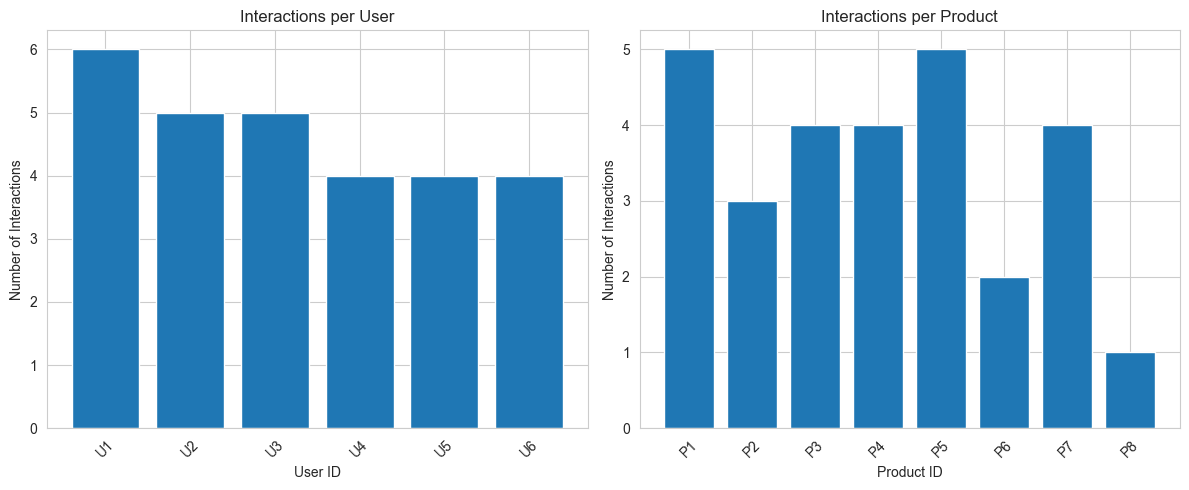


User interactions: [6 5 5 4 4 4]
Product interactions: [5 3 4 4 5 2 4 1]


In [30]:
# User interaction distribution
user_counts = interactions_df['user_id'].value_counts().sort_index()
item_counts = interactions_df['item_id'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# User interactions
axes[0].bar(range(len(user_counts)), user_counts.values)
axes[0].set_xlabel('User ID')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_title('Interactions per User')
axes[0].set_xticks(range(len(user_counts)))
axes[0].set_xticklabels(user_counts.index, rotation=45)

# Item interactions
axes[1].bar(range(len(item_counts)), item_counts.values)
axes[1].set_xlabel('Product ID')
axes[1].set_ylabel('Number of Interactions')
axes[1].set_title('Interactions per Product')
axes[1].set_xticks(range(len(item_counts)))
axes[1].set_xticklabels(item_counts.index, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nUser interactions: {user_counts.values}")
print(f"Product interactions: {item_counts.values}")

## 5. Sparsity Analysis

Sparsity Analysis:
  Users: 6
  Items: 8
  Possible interactions: 48
  Actual interactions: 28
  Sparsity: 41.67%
  Density: 58.33%


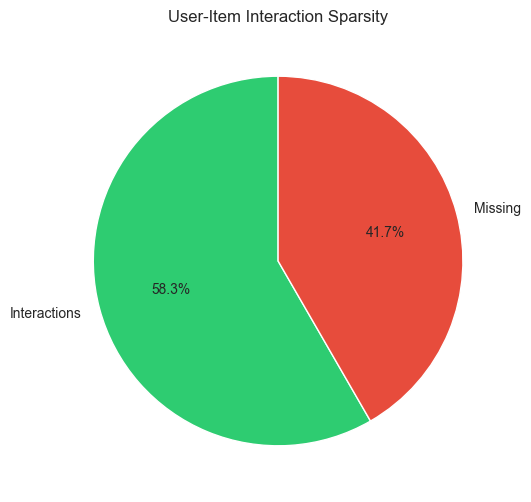

In [31]:
# Calculate sparsity
n_users = interactions_df['user_id'].nunique()
n_items = interactions_df['item_id'].nunique()
n_interactions = len(interactions_df)
possible_interactions = n_users * n_items
sparsity = 1 - (n_interactions / possible_interactions)

print(f"Sparsity Analysis:")
print(f"  Users: {n_users}")
print(f"  Items: {n_items}")
print(f"  Possible interactions: {possible_interactions}")
print(f"  Actual interactions: {n_interactions}")
print(f"  Sparsity: {sparsity:.2%}")
print(f"  Density: {(1-sparsity):.2%}")

# Visualize sparsity
fig, ax = plt.subplots(figsize=(8, 6))
categories = ['Interactions', 'Missing']
values = [n_interactions, possible_interactions - n_interactions]
colors = ['#2ecc71', '#e74c3c']
ax.pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('User-Item Interaction Sparsity')
plt.show()

## 6. Product Categories

In [32]:
# Analyze product categories
print("Product Categories:")
print(products_df['category'].value_counts())
print("\nAll Products:")
print(products_df[['product_id', 'product_name', 'category']].to_string())

Product Categories:
category
Electronics    3
Groceries      2
Home           1
Accessories    1
Stationery     1
Name: count, dtype: int64

All Products:
  product_id      product_name     category
0         P1      Coffee Beans    Groceries
1         P2    Coffee Filters    Groceries
2         P3       Ceramic Mug         Home
3         P4            Laptop  Electronics
4         P5    Wireless Mouse  Electronics
5         P6     Laptop Sleeve  Accessories
6         P7        Headphones  Electronics
7         P8  Notebook (Paper)   Stationery


## 7. Interaction Matrix Visualization

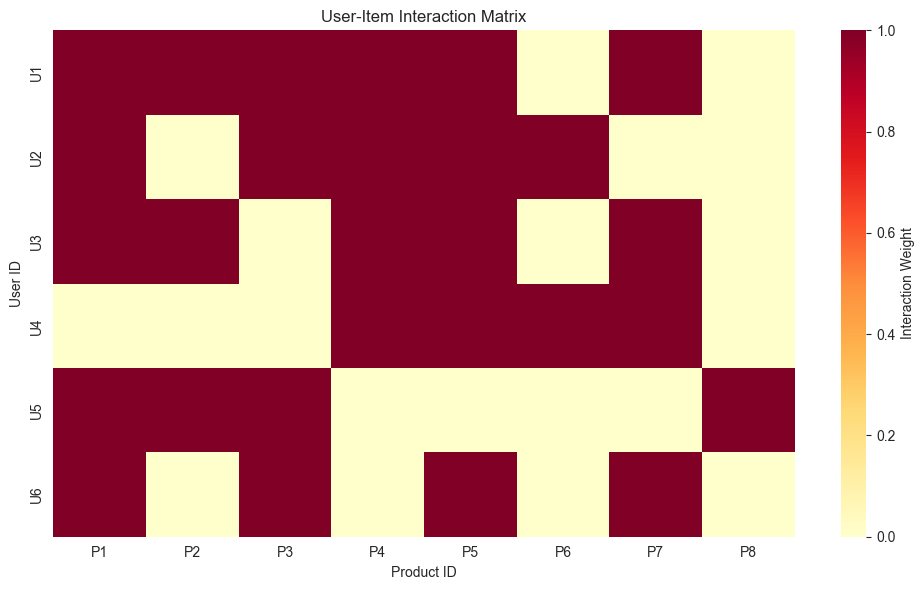

Interaction Matrix created successfully


In [34]:
# Create interaction matrix heatmap
interaction_matrix = interactions_df.pivot_table(
    index='user_id', 
    columns='item_id', 
    values='rating', 
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(interaction_matrix, cmap='YlOrRd', cbar_kws={'label': 'Interaction Weight'})
plt.title('User-Item Interaction Matrix')
plt.xlabel('Product ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

print("Interaction Matrix created successfully")

## Summary

Dataset Overview:
- **Source**: RetailRocket eCommerce dataset
- **Events**: Click, add to cart, purchase
- **Purpose**: Train collaborative filtering and association rule mining models
- **Next**: Proceed to individual algorithm notebooks